In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
import kagglehub
from pathlib import Path

c:\Users\madha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download dataset
try:
    path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
    csv_path = Path(path) / "DailyDelhiClimateTrain.csv"
except Exception as exc:
    raise RuntimeError(
        "Kaggle dataset download failed. Configure Kaggle access for kagglehub and run this cell again."
    ) from exc

print("Dataset path:", csv_path)

Dataset path: C:\Users\madha\.cache\kagglehub\datasets\sumanthvrao\daily-climate-time-series-data\versions\3\DailyDelhiClimateTrain.csv


In [4]:
# Load dataset
data = pd.read_csv(csv_path)
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
temp = data["meantemp"].to_numpy()

rolling_temp = data["meantemp"].rolling(window=15, center=True, min_periods=1).mean()
smooth_temp = rolling_temp.ewm(span=10, adjust=False).mean().to_numpy()

split_index = int(len(smooth_temp) * 0.8)
train_mean = smooth_temp[:split_index].mean()
train_std = smooth_temp[:split_index].std()
train_std = train_std if train_std > 0 else 1.0

observations = ((smooth_temp - train_mean) / train_std).reshape(-1, 1)
train_data = observations[:split_index]
test_data = observations[split_index:]

print(pd.DataFrame({
    "temperature": temp[:10],
    "smoothed_temperature": smooth_temp[:10]
}))

   temperature  smoothed_temperature
0    10.000000              7.761310
1     7.400000              7.887344
2     7.166667              8.036744
3     8.666667              8.274770
4     6.000000              8.540036
5     7.000000              8.842380
6     7.000000              9.123914
7     8.857143              9.406666
8    14.000000              9.684472
9    11.000000             10.022072


In [6]:
model = hmm.GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=50,
    min_covar=0.5,
    random_state=42
    )

model.fit(train_data)

GaussianHMM(min_covar=0.5, n_components=2, n_iter=50, random_state=42)

In [7]:
hidden_states = model.predict(observations)

print("Hidden state counts:", np.bincount(hidden_states))

Hidden state counts: [666 796]


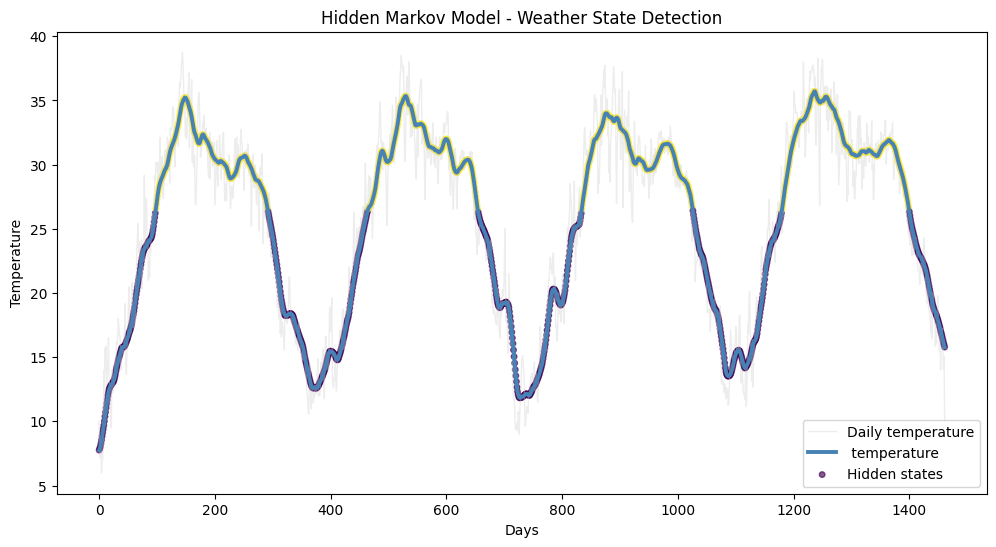

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(temp, color="lightgray", alpha=0.4, linewidth=1.0, label="Daily temperature")
plt.plot(smooth_temp, color="steelblue", linewidth=2.8, label=" temperature")
plt.scatter(
    range(len(hidden_states)),
    smooth_temp,
    c=hidden_states,
    cmap="viridis",
    s=16,
    alpha=0.65,
    label="Hidden states"
)

plt.title("Hidden Markov Model - Weather State Detection")
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.legend()
plt.show()

In [10]:
train_score = model.score(train_data) / len(train_data)
test_score = model.score(test_data) / len(test_data)
full_score = model.score(observations) / len(observations)
overfit_gap = train_score - test_score

print("Train Log Likelihood per sample:", train_score)
print("Test Log Likelihood per sample:", test_score)
print("Full-series Log Likelihood per sample:", full_score)


Train Log Likelihood per sample: -0.555334204720919
Test Log Likelihood per sample: -0.5266699805523606
Full-series Log Likelihood per sample: -0.5495931552422518
